In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 
import yfinance as yf
import scipy.stats as stats

In [2]:
df = pd.read_excel("../financial_data/vinfast_stock_data.xlsx")

In [3]:
df

,Date,Open,High,Low,CloseClosing price adjusted for splits.,Adj CloseAdjusted closing price adjusted for splits and dividend and/or capital gain distributions.,Volume
0,2026-04-28 00:00:00,4.16,4.195,4.000,4.060,4.060,834600
1,2026-04-27 00:00:00,4.23,4.340,4.157,4.210,4.210,650700
2,2026-04-24 00:00:00,4.41,4.450,4.335,4.360,4.360,457200
3,2026-04-23 00:00:00,4.57,4.605,4.140,4.410,4.410,1333100
4,2026-04-22 00:00:00,4.88,5.120,4.580,4.690,4.690,1409000
...,...,...,...,...,...,...,...
1160,13 Sept 2021,9.71,9.710,9.710,9.710,9.710,400
1161,10 Sept 2021,9.69,9.690,9.680,9.680,9.680,700
1162,9 Sept 2021,9.61,9.691,9.610,9.682,9.682,400
1163,8 Sept 2021,9.71,9.710,9.710,9.710,9.710,3700


In [4]:
df.columns = ['date', 'open', 'high', 'low', 'close', 'adjusted_close', 'volume']

df['date'] = pd.to_datetime(df['date'], format='mixed')

In [5]:
df

,date,open,high,low,close,adjusted_close,volume
0,2026-04-28,4.16,4.195,4.000,4.060,4.060,834600
1,2026-04-27,4.23,4.340,4.157,4.210,4.210,650700
2,2026-04-24,4.41,4.450,4.335,4.360,4.360,457200
3,2026-04-23,4.57,4.605,4.140,4.410,4.410,1333100
4,2026-04-22,4.88,5.120,4.580,4.690,4.690,1409000
...,...,...,...,...,...,...,...
1160,2021-09-13,9.71,9.710,9.710,9.710,9.710,400
1161,2021-09-10,9.69,9.690,9.680,9.680,9.680,700
1162,2021-09-09,9.61,9.691,9.610,9.682,9.682,400
1163,2021-09-08,9.71,9.710,9.710,9.710,9.710,3700


In [6]:
df.isna().sum()

date              0
open              0
high              0
low               0
close             0
adjusted_close    0
volume            0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df['date'] = pd.to_datetime(df['date'], format="mixed")


In [9]:
df = df.sort_values(['date'],ascending=True) 
df


,date,open,high,low,close,adjusted_close,volume
1164,2021-09-07,9.93,9.980,9.797,9.797,9.797,3700
1163,2021-09-08,9.71,9.710,9.710,9.710,9.710,3700
1162,2021-09-09,9.61,9.691,9.610,9.682,9.682,400
1161,2021-09-10,9.69,9.690,9.680,9.680,9.680,700
1160,2021-09-13,9.71,9.710,9.710,9.710,9.710,400
...,...,...,...,...,...,...,...
4,2026-04-22,4.88,5.120,4.580,4.690,4.690,1409000
3,2026-04-23,4.57,4.605,4.140,4.410,4.410,1333100
2,2026-04-24,4.41,4.450,4.335,4.360,4.360,457200
1,2026-04-27,4.23,4.340,4.157,4.210,4.210,650700


In [10]:
df.corr(numeric_only=True)

,open,high,low,close,adjusted_close
open,1.000000,0.977757,0.981945,0.966715,0.966715
high,0.977757,1.000000,0.964280,0.985586,0.985586
low,0.981945,0.964280,1.000000,0.982141,0.982141
close,0.966715,0.985586,0.982141,1.000000,1.000000
adjusted_close,0.966715,0.985586,0.982141,1.000000,1.000000


In [11]:
plt.style.use("bmh")

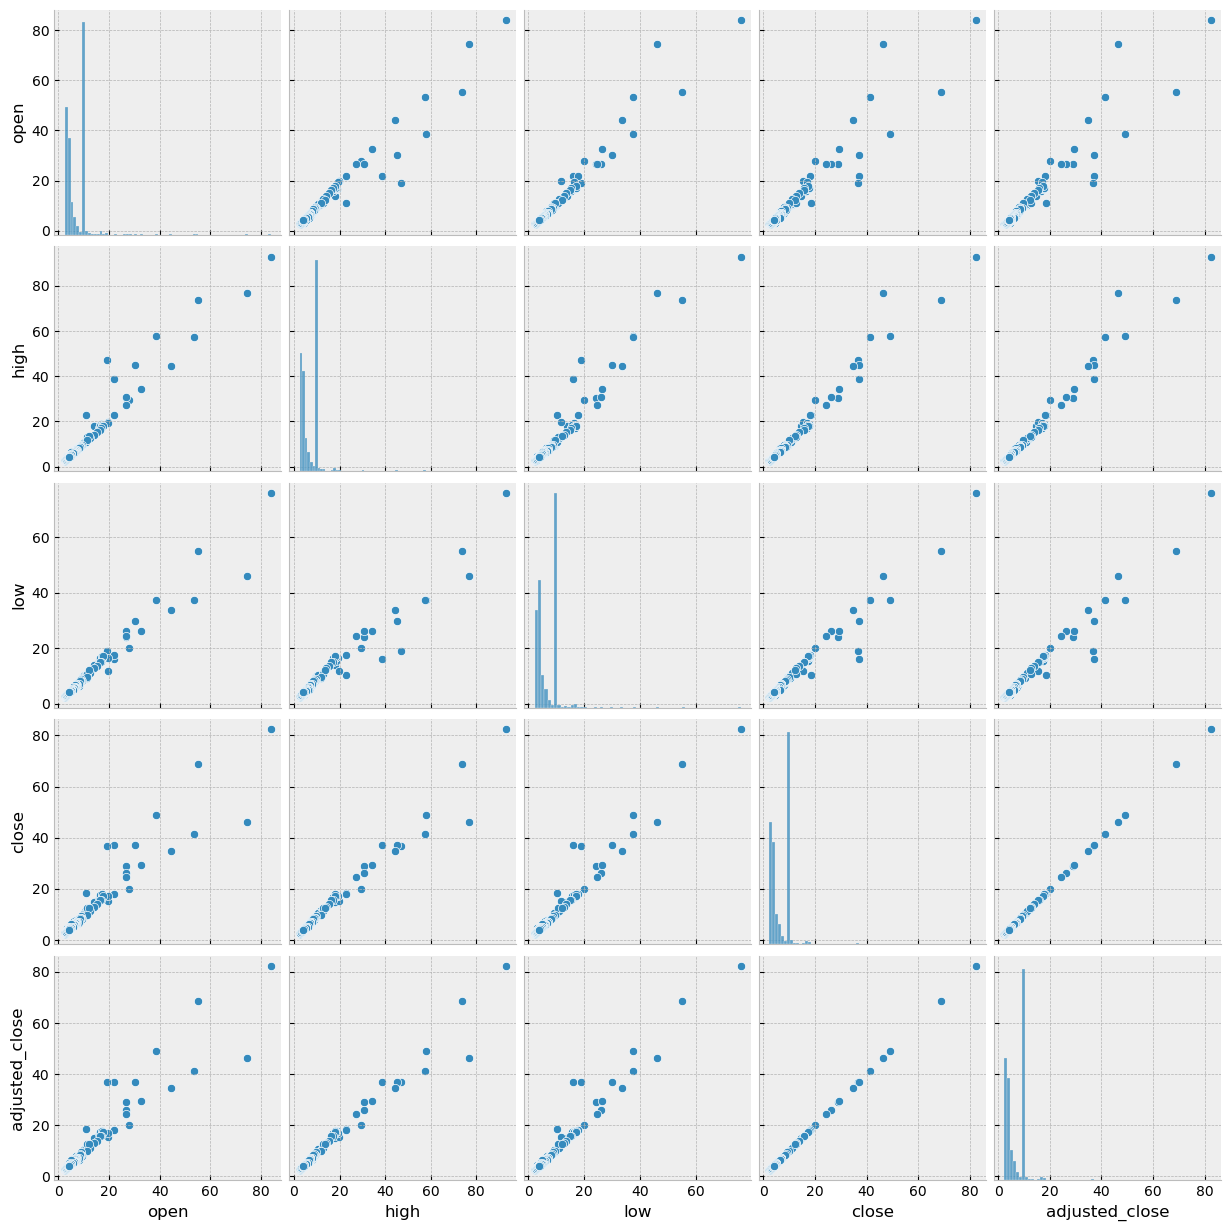

In [12]:
sns.pairplot(df)

In [13]:
df.index = df.date 
df.drop(['date'],axis=1,inplace=True) 


In [14]:
df

,open,high,low,close,adjusted_close,volume
date,,,,,,
2021-09-07,9.93,9.980,9.797,9.797,9.797,3700
2021-09-08,9.71,9.710,9.710,9.710,9.710,3700
2021-09-09,9.61,9.691,9.610,9.682,9.682,400
2021-09-10,9.69,9.690,9.680,9.680,9.680,700
2021-09-13,9.71,9.710,9.710,9.710,9.710,400
...,...,...,...,...,...,...
2026-04-22,4.88,5.120,4.580,4.690,4.690,1409000
2026-04-23,4.57,4.605,4.140,4.410,4.410,1333100
2026-04-24,4.41,4.450,4.335,4.360,4.360,457200


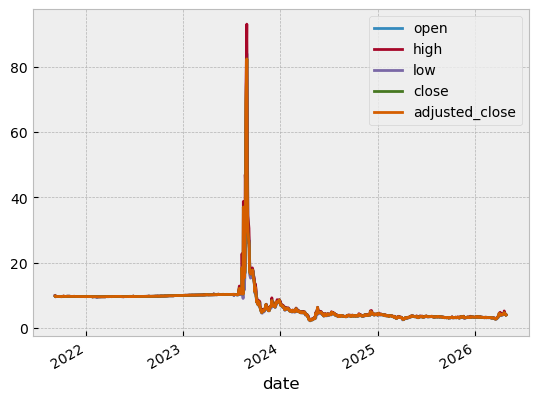

In [15]:
plt.Figure(figsize=(10,10))
df.plot(kind='line')

plt.show()

In [16]:
df.head()

,open,high,low,close,adjusted_close,volume
date,,,,,,
2021-09-07,9.93,9.980,9.797,9.797,9.797,3700
2021-09-08,9.71,9.710,9.710,9.710,9.710,3700
2021-09-09,9.61,9.691,9.610,9.682,9.682,400
2021-09-10,9.69,9.690,9.680,9.680,9.680,700
2021-09-13,9.71,9.710,9.710,9.710,9.710,400


In [17]:
df.reset_index(inplace=True)

In [18]:
df

,date,open,high,low,close,adjusted_close,volume
0,2021-09-07,9.93,9.980,9.797,9.797,9.797,3700
1,2021-09-08,9.71,9.710,9.710,9.710,9.710,3700
2,2021-09-09,9.61,9.691,9.610,9.682,9.682,400
3,2021-09-10,9.69,9.690,9.680,9.680,9.680,700
4,2021-09-13,9.71,9.710,9.710,9.710,9.710,400
...,...,...,...,...,...,...,...
1160,2026-04-22,4.88,5.120,4.580,4.690,4.690,1409000
1161,2026-04-23,4.57,4.605,4.140,4.410,4.410,1333100
1162,2026-04-24,4.41,4.450,4.335,4.360,4.360,457200
1163,2026-04-27,4.23,4.340,4.157,4.210,4.210,650700


In [19]:
df = df.sort_values(['date'],ascending=True)

df = df[df.date > '2024-01-01']

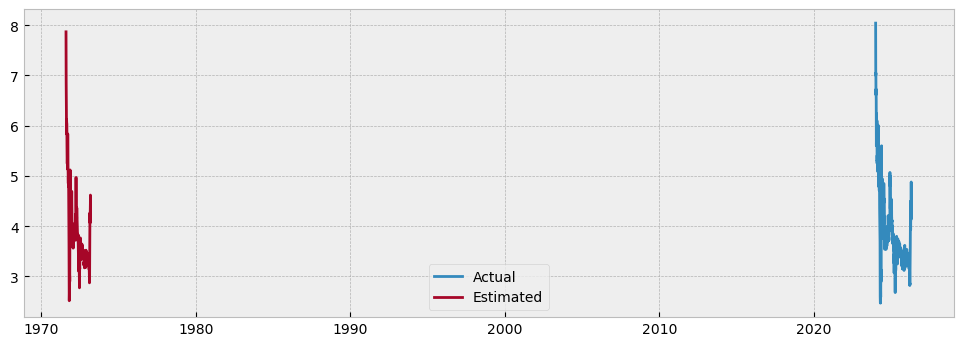

In [20]:
from statsmodels.tsa.seasonal import STL
open_price = pd.DataFrame(df[['open', 'date']])


stl = STL(open_price['open'], period=3) 
result = stl.fit()
seasonal, trend, resid = result.seasonal, result.trend, result.resid 


estimated = trend + seasonal 
plt.figure(figsize=(12,4)) 
plt.plot(open_price.date, open_price.open) 
plt.plot(estimated) 
plt.legend(['Actual', 'Estimated'])
plt.show()

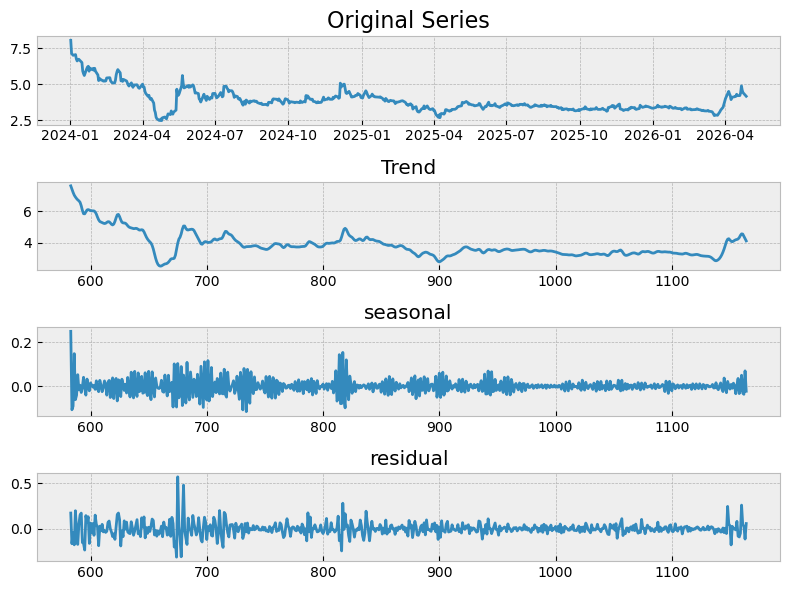

In [21]:
seasonal, trend, resid = result.seasonal, result.trend, result.resid 

plt.figure(figsize=(8,6)) 
plt.subplot(4,1,1) 
plt.plot(df.date, df['open']) 
plt.title("Original Series", fontsize=16) 

plt.subplot(4,1,2)
plt.plot(trend)
plt.title("Trend") 

plt.subplot(4,1,3) 
plt.plot(seasonal) 
plt.title("seasonal") 

plt.subplot(4,1,4) 
plt.plot(resid) 
plt.title("residual")
plt.tight_layout()

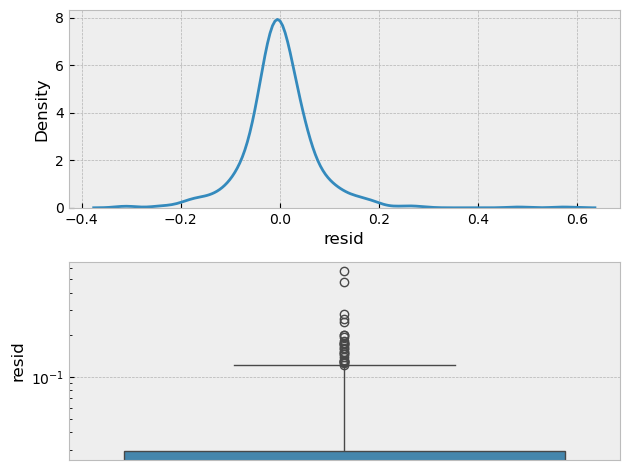

Shapiro -> ShapiroResult(statistic=0.8899385112825087, pvalue=5.828630661555075e-20)


In [22]:
fig, axes=plt.subplots(2) 

sns.kdeplot(resid, ax=axes[0])
sns.boxplot(resid, ax=axes[1])
axes[1].set_yscale("log") 
plt.tight_layout()
plt.show()

import scipy.stats as stats 


print (f"Shapiro -> {stats.shapiro(resid)}")

In [23]:
df

,date,open,high,low,close,adjusted_close,volume
583,2024-01-02,8.040,8.050,7.000,7.05,7.05,6666200
584,2024-01-03,7.135,7.210,6.835,7.08,7.08,4709600
585,2024-01-04,7.070,7.130,6.900,7.07,7.07,3466600
586,2024-01-05,7.000,7.060,6.900,7.02,7.02,1939900
587,2024-01-08,7.050,7.190,6.750,6.79,6.79,3767900
...,...,...,...,...,...,...,...
1160,2026-04-22,4.880,5.120,4.580,4.69,4.69,1409000
1161,2026-04-23,4.570,4.605,4.140,4.41,4.41,1333100
1162,2026-04-24,4.410,4.450,4.335,4.36,4.36,457200
1163,2026-04-27,4.230,4.340,4.157,4.21,4.21,650700


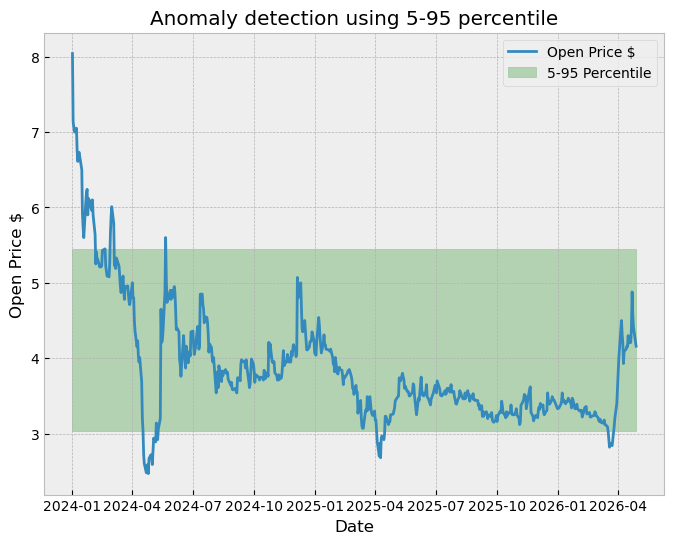

In [24]:
plt.figure(figsize=(8,6))
plt.plot(df.date, df.open) 

# plotting the median lines 

upper = np.percentile(df.open, 95) 
lower = np.percentile(df.open, 5) 

plt.fill_between([df.date.min(), df.date.max()], lower, upper, color='g', alpha=0.25) 
plt.title("Anomaly detection using 5-95 percentile") 
plt.ylabel("Open Price $") 
plt.xlabel("Date")

plt.legend(['Open Price $', '5-95 Percentile'])
plt.show()

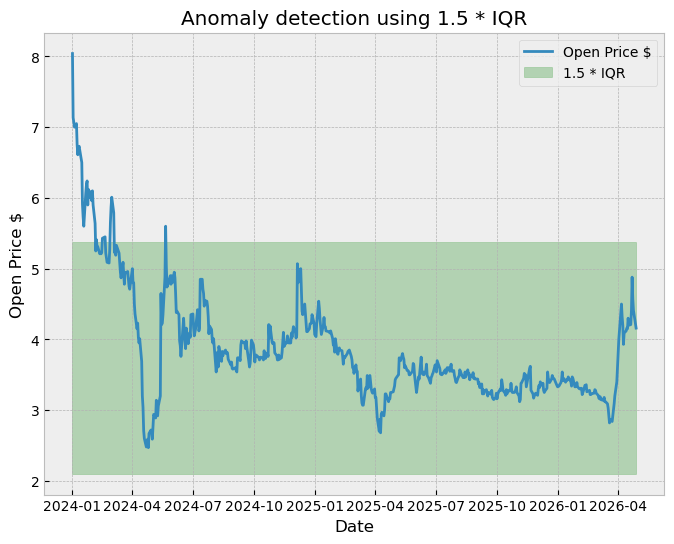

In [25]:
# using IQR

iqr = stats.iqr(df['open']) 




plt.figure(figsize=(8,6))
plt.plot(df.date, df.open) 

# plotting the median lines 

upper = (1.5 * iqr) + np.percentile(df.open, 75)
lower = np.percentile(df.open, 25) - (1.5 * iqr)

plt.fill_between([df.date.min(), df.date.max()], lower, upper, color='g', alpha=0.25) 
plt.title("Anomaly detection using 1.5 * IQR") 
plt.ylabel("Open Price $") 
plt.xlabel("Date")

plt.legend(['Open Price $', '1.5 * IQR'])
plt.show()

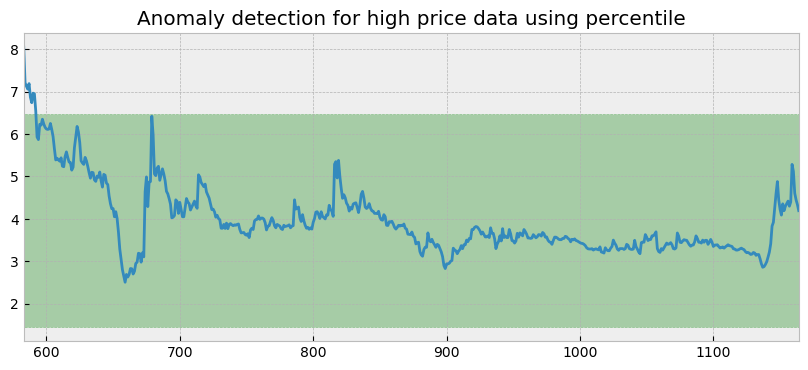

In [26]:
# checking if datapoints fit within 3 * std of mean
open_mu = df['high'].mean() 
open_dev = df['high'].std() 

lower=open_mu - 3 * open_dev 
upper = open_mu + 3 * open_dev 
plt.figure(figsize=(10,4)) 
plt.plot(df.index, df.high) 
plt.fill_between([min(df.index), max(df.index)], lower, upper, color='g', alpha=0.3, linestyle='--')
plt.xlim(min(df.index), max(df.index))
plt.title("Anomaly detection for high price data using percentile")
plt.show()

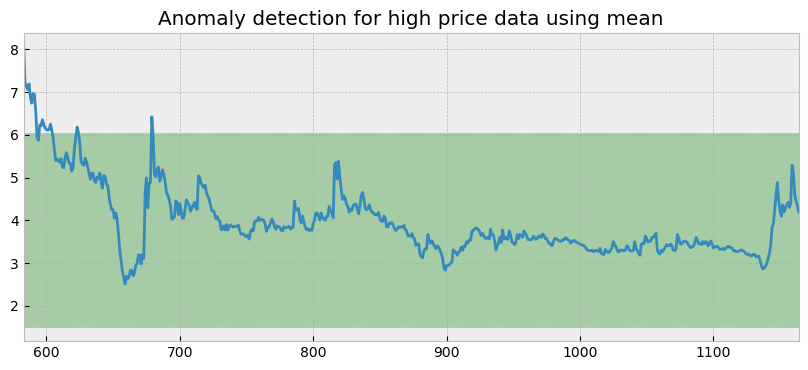

In [27]:
# checking if datapoints fit within 3 * std of mean
open_mu = df['low'].mean() 
open_dev = df['low'].std() 

lower=open_mu - 3 * open_dev 
upper = open_mu + 3 * open_dev 
plt.figure(figsize=(10,4)) 
plt.plot(df.index, df.high) 
plt.fill_between([min(df.index), max(df.index)], lower, upper, color='g', alpha=0.3, linestyle='--')
plt.xlim(min(df.index), max(df.index))
plt.title("Anomaly detection for high price data using mean")
plt.show()

In [28]:

df.volume = pd.to_numeric(df.volume)

{'whiskers': [<matplotlib.lines.Line2D at 0x15ac07ad0>,
 'caps': [<matplotlib.lines.Line2D at 0x15ac2c050>,
 'boxes': [<matplotlib.lines.Line2D at 0x15ac07830>],
 'medians': [<matplotlib.lines.Line2D at 0x15ac2c500>],
 'fliers': [<matplotlib.lines.Line2D at 0x15ac2c830>],
 'means': []}

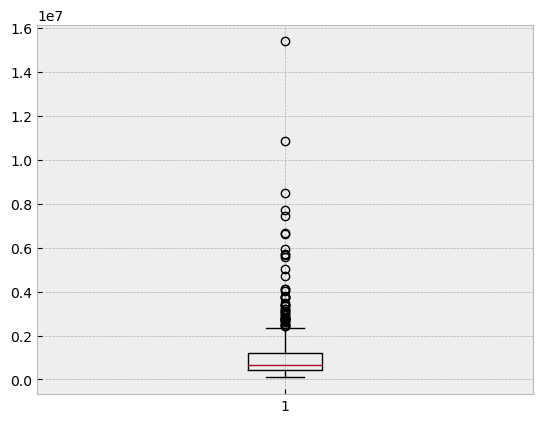

In [29]:
plt.boxplot(df.volume)

In [30]:
min(df.volume)

98200

In [31]:
df.iloc[5]

date              2024-01-09 00:00:00
open                             6.75
high                             6.87
low                              6.41
close                            6.65
adjusted_close                   6.65
volume                        3327700
Name: 588, dtype: object

In [32]:
df.reset_index(inplace=True)

In [33]:
df.head()

,index,date,open,high,low,close,adjusted_close,volume
0,583,2024-01-02,8.040,8.05,7.000,7.05,7.05,6666200
1,584,2024-01-03,7.135,7.21,6.835,7.08,7.08,4709600
2,585,2024-01-04,7.070,7.13,6.900,7.07,7.07,3466600
3,586,2024-01-05,7.000,7.06,6.900,7.02,7.02,1939900
4,587,2024-01-08,7.050,7.19,6.750,6.79,6.79,3767900


In [34]:
df.drop(['index'],axis=1,inplace=True)

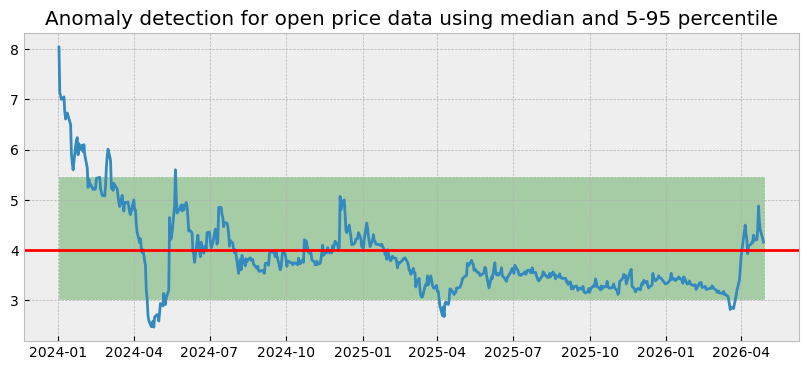

In [35]:


lower=np.percentile(df.open, 5)
upper = np.percentile(df.open, 95) 
plt.figure(figsize=(10,4)) 
plt.plot(df.date, df.open) 
plt.fill_between([min(df.date), max(df.date)], lower, upper, color='g', alpha=0.3, linestyle='--')


plt.axhline(y=4, color='r')
plt.title("Anomaly detection for open price data using median and 5-95 percentile")
plt.show()

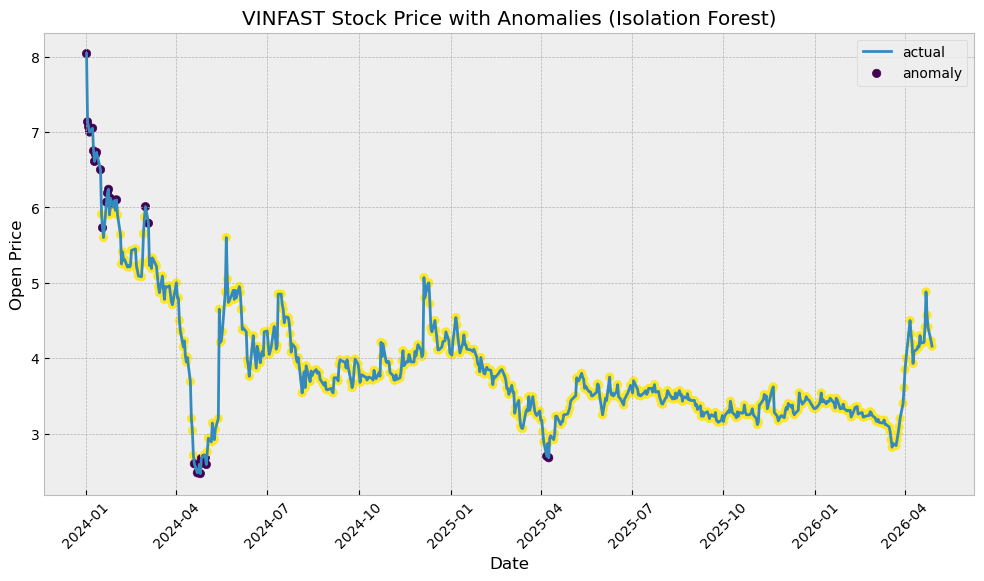

In [36]:
from sklearn.ensemble import IsolationForest

# Prepare the data for Isolation Forest
X = df['open'].values.reshape(-1, 1)

# Train the Isolation Forest model
model = IsolationForest(contamination=0.05)
model.fit(X)

# Predict the anomalies
anomalies = model.predict(X)

# Plot the anomalies
plt.figure(figsize=(12, 6))
plt.plot(df.date, df['open'])
plt.scatter(df.date, df['open'], c=anomalies, label='Anomaly')
plt.xlabel('Date')
plt.ylabel('Open Price')
plt.title('VINFAST Stock Price with Anomalies (Isolation Forest)')
plt.xticks(rotation=45)
plt.legend(['actual', 'anomaly'])
plt.grid(True)

plt.show()

In [37]:
anomalies

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1,  1, -1, -1, -1,  1,
       -1, -1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1, -1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1, -1, -1, -1, -1, -1,  1, -1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

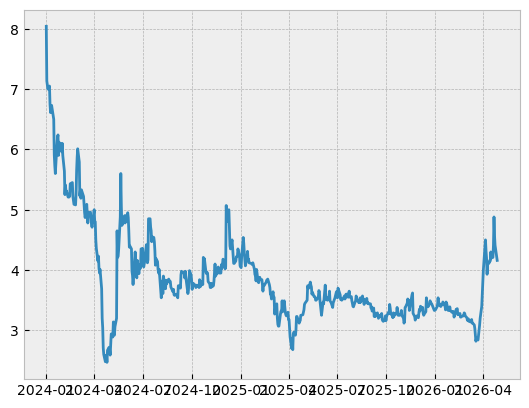

In [38]:
plt.plot(df.date, df.open)

# Building the model

In [39]:
from sklearn.model_selection import train_test_split, GridSearchCV 
from xgboost import XGBRegressor


## using the cleaning script

In [40]:
import sys 
sys.path.append("../scripts/") 
from clean_time_series import clean_iqr

This script is based on the idea that you wish to use lagging stock values to predict future stock values
Make sure you have cleaned your data first
This script is for preprocessing for modelling...
The date should be within the index


In [41]:
df.head()

,date,open,high,low,close,adjusted_close,volume
0,2024-01-02,8.040,8.05,7.000,7.05,7.05,6666200
1,2024-01-03,7.135,7.21,6.835,7.08,7.08,4709600
2,2024-01-04,7.070,7.13,6.900,7.07,7.07,3466600
3,2024-01-05,7.000,7.06,6.900,7.02,7.02,1939900
4,2024-01-08,7.050,7.19,6.750,6.79,6.79,3767900


In [42]:
y = df.open.values.reshape(-1,1) 
np.shape(y)[0]

582

In [43]:
y = np.delete(y, 0)
len(y)

581

In [44]:
len(df)

582

In [45]:
# predicting opening price 


# sorting the data by date

df = df.sort_values(['date'],ascending=True)


X = df.drop(['open', 'close', 'volume'],axis=1) 


y = df.open.values.reshape(-1,1) 
# lagging the y
y_lag = np.delete(y, 0)


train_size=round(len(df) * 0.8)
test_size=round(len(df) * 0.2) 



# creating the train/test split 
X_train = X.head(train_size) 
X_test = X.tail(test_size) 

Y_train = y_lag[0:round(len(y_lag) * 0.8)]
Y_test = y_lag[train_size:np.shape(y)[0]]


# fittign the cleaner
X_train = clean_iqr(X_train) 
column_stats = X_train.fit() 

X_train_transformed = X_train.fit_transform()

X_test_transformed = X_train.transform(column_stats=column_stats, dataframe=X_test)



Calculating the upper, lower, median and iqr...
Analysing column: high
Analysing column: low
Analysing column: adjusted_close
Using the 1.5 * IQR method for anomaly detection...
Analysing column: high
Analysing column: low
Analysing column: adjusted_close
`day` is a datetime. Ignoring this...
`month` is a datetime. Ignoring this...
`year` is a datetime. Ignoring this...
Transforming... Dataframe
median: [3.83]
upper: [5.6625]
lower: [2.1865]
Transforming... Dataframe
median: [3.6875]
upper: [5.152875]
lower: [2.291875]
Transforming... Dataframe
median: [3.75]
upper: [5.42375]
lower: [2.23375]


/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:154: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df.drop(['date'],axis=1,inplace=True)
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:155: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df['day'] = self.df.index.day
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:156: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

In [46]:
X

,date,high,low,adjusted_close
0,2024-01-02,8.050,7.000,7.05
1,2024-01-03,7.210,6.835,7.08
2,2024-01-04,7.130,6.900,7.07
3,2024-01-05,7.060,6.900,7.02
4,2024-01-08,7.190,6.750,6.79
...,...,...,...,...
577,2026-04-22,5.120,4.580,4.69
578,2026-04-23,4.605,4.140,4.41
579,2026-04-24,4.450,4.335,4.36
580,2026-04-27,4.340,4.157,4.21


In [47]:
X_train_transformed = X_train_transformed.drop(['high', 'low', 'adjusted_close'], axis=1)

X_test_transformed = X_test_transformed.drop(['high', 'low', 'adjusted_close'], axis=1)

In [48]:
X_train_transformed

,day,month,year,high_iqr_imputed,low_iqr_imputed,adjusted_close_iqr_imputed
date,,,,,,
2024-01-02,2,1,2024,3.830,3.6875,3.75
2024-01-03,3,1,2024,3.830,3.6875,3.75
2024-01-04,4,1,2024,3.830,3.6875,3.75
2024-01-05,5,1,2024,3.830,3.6875,3.75
2024-01-08,8,1,2024,3.830,3.6875,3.75
...,...,...,...,...,...,...
2025-11-03,3,11,2025,3.220,3.1300,3.18
2025-11-04,4,11,2025,3.180,3.1000,3.14
2025-11-05,5,11,2025,3.440,3.1400,3.40


In [49]:
# building the lagging
X_train_transformed = X_train.build_lagging(dataframe=X_train_transformed)
X_test_transformed = X_train.build_lagging(dataframe=X_test_transformed)

Created the lagged values...
Removing the first row
Created the lagged values...
Removing the first row


In [50]:
X_train_transformed.drop(['high_iqr_imputed', 'low_iqr_imputed', 'adjusted_close_iqr_imputed'], axis=1, inplace=True)


X_test_transformed.drop(['high_iqr_imputed', 'low_iqr_imputed', 'adjusted_close_iqr_imputed'], axis=1, inplace=True)


/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_33987/3664342084.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_transformed.drop(['high_iqr_imputed', 'low_iqr_imputed', 'adjusted_close_iqr_imputed'], axis=1, inplace=True)


In [51]:
X_train_transformed.columns

Index(['day', 'month', 'year', 'lagged_high_iqr_imputed',
       'lagged_low_iqr_imputed', 'lagged_adjusted_close_iqr_imputed'],
      dtype='object')

In [52]:
print (np.shape(X_train_transformed)) 
print (np.shape(Y_train)) 
print ("---")
print (np.shape(X_test_transformed)) 
print (np.shape(Y_test))

(465, 6)
(465,)
---
(115, 6)
(115,)


In [53]:
import joblib

In [54]:
model = XGBRegressor()

model.fit(X_train_transformed, Y_train)


pred = model.predict(X_test_transformed)

In [55]:
# metrics
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

In [56]:
print (root_mean_squared_error(y_pred=pred, y_true=Y_test))
print (mean_absolute_error(y_pred=pred, y_true=Y_test))
print (r2_score(y_true=Y_test, y_pred=pred))


0.0827862881309866
0.05345583822830863
0.9553534409661596


In [57]:
df.tail(test_size).date

466   2025-11-10
467   2025-11-11
468   2025-11-12
469   2025-11-13
470   2025-11-14
         ...    
577   2026-04-22
578   2026-04-23
579   2026-04-24
580   2026-04-27
581   2026-04-28
Name: date, Length: 116, dtype: datetime64[ns]

In [58]:
np.shape(pred)

(115,)

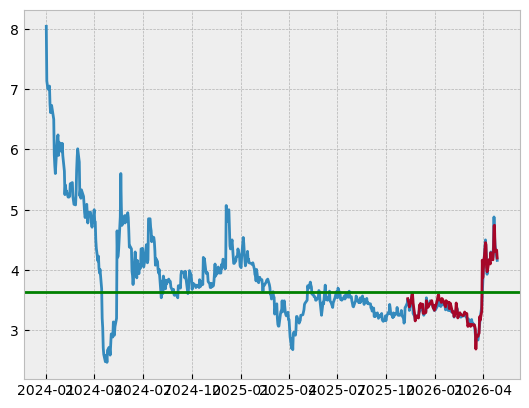

In [59]:
# plotting


plt.plot(df.date, df.open)
plt.plot(df.tail(test_size).date.iloc[1:], pred)

plt.axhline(y=df['open'].median(), color='g')

Text(0.5, 1.0, 'Zoomed in VINFAST opening prices prediction. R2 = 0.955')

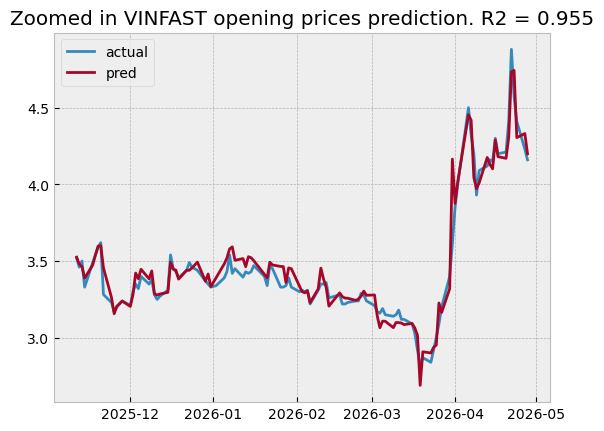

In [60]:
plt.plot(df.tail(test_size).date.iloc[1:], Y_test)
plt.plot(df.tail(test_size).date.iloc[1:], pred)

plt.legend(['actual', 'pred'])

plt.title(f"Zoomed in VINFAST opening prices prediction. R2 = {np.round(r2_score(y_true=Y_test, y_pred=pred), 3)}")

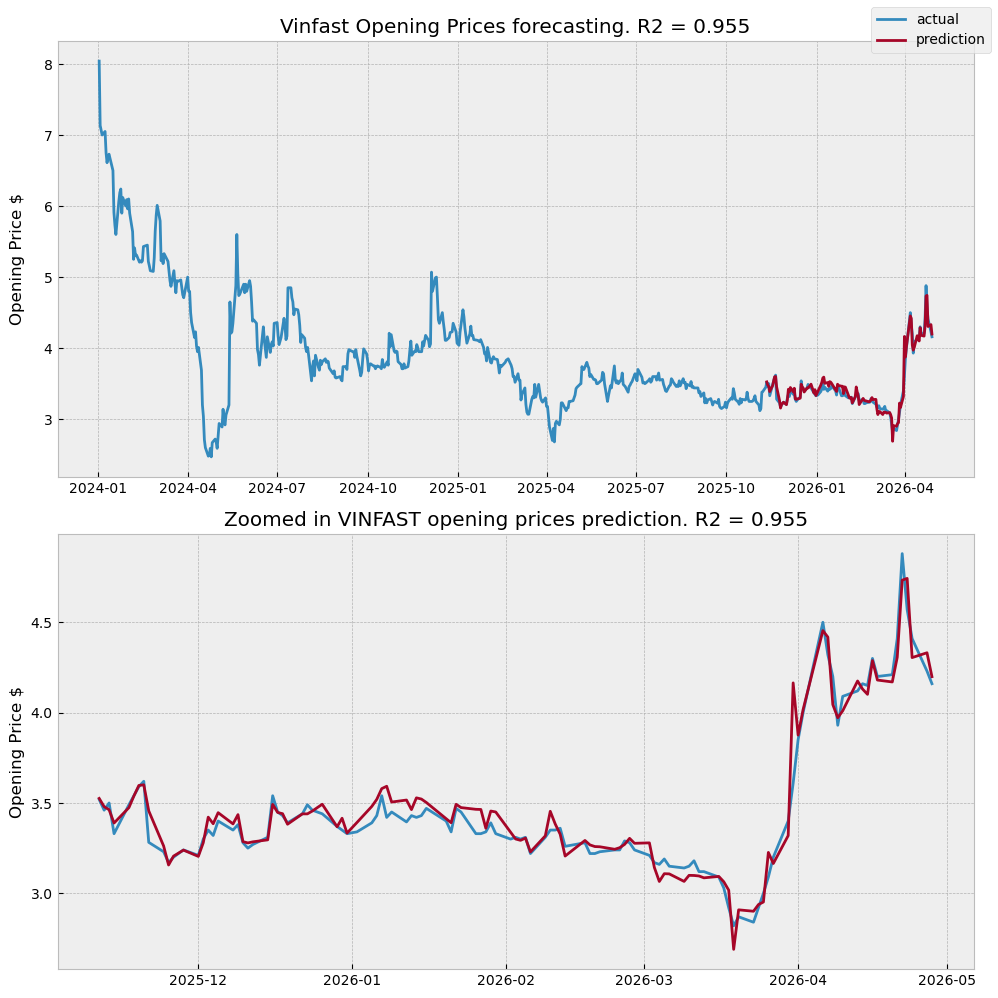

In [61]:
# plotting

fig, axes=plt.subplots(2, figsize=(10,10))




axes[0].plot(df.date, df.open)
axes[0].plot(df.tail(test_size).date.iloc[1:], pred)



axes[0].set_title(f"Vinfast Opening Prices forecasting. R2 = {np.round(r2_score(y_true=Y_test, y_pred=pred), 3)}")
axes[0].set_ylabel("Opening Price $")

# ---------

axes[1].plot(df.tail(test_size).date.iloc[1:], Y_test)
axes[1].plot(df.tail(test_size).date.iloc[1:], pred)



axes[1].set_title(f"Zoomed in VINFAST opening prices prediction. R2 = {np.round(r2_score(y_true=Y_test, y_pred=pred), 3)}")
axes[1].set_ylabel("Opening Price $")
fig.legend(['actual', 'prediction'])

fig.align_ylabels()

plt.tight_layout()
plt.show()

Text(0.5, 0, 'Y test')

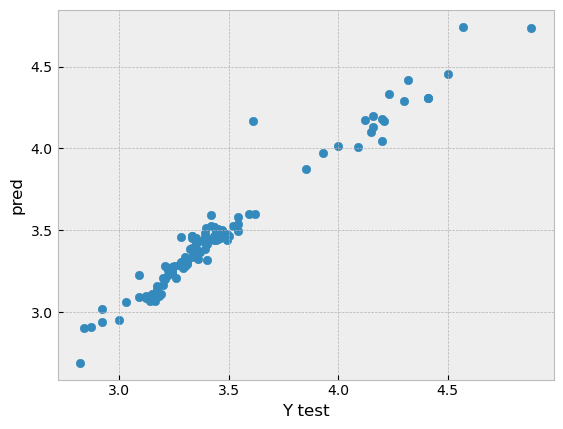

In [62]:
plt.scatter(Y_test, pred) 
plt.ylabel("pred") 
plt.xlabel("Y test")

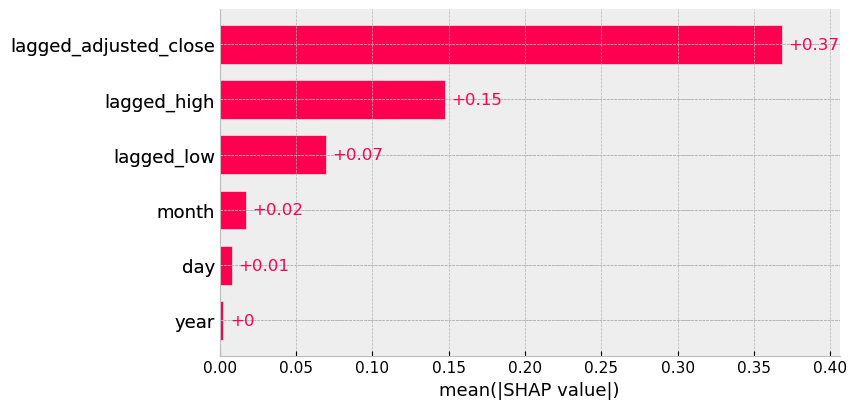

In [69]:
import shap 


explainer = shap.TreeExplainer(model) 
shap_values = explainer(X_test) 


shap.plots.bar(shap_values)

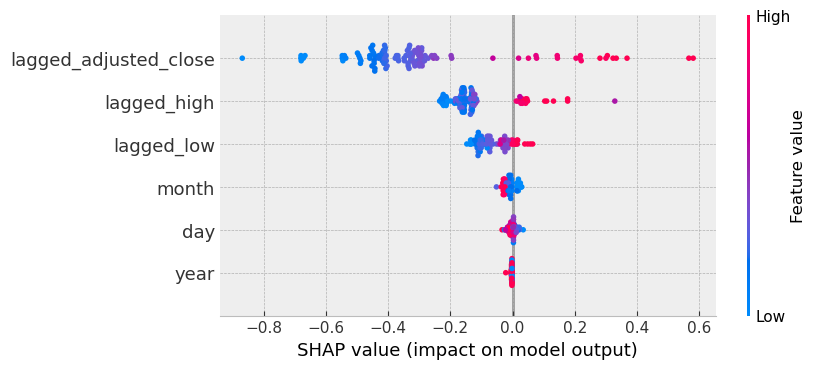

In [248]:
shap.plots.beeswarm(shap_values)

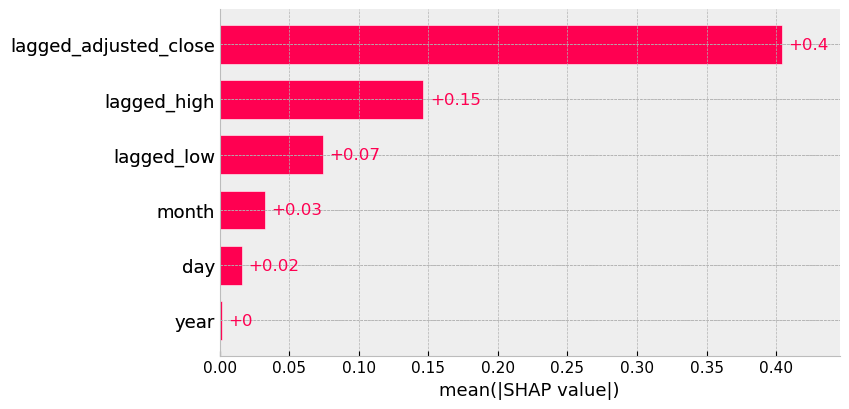

In [249]:



train_shap_values = explainer(X_train) 


shap.plots.bar(train_shap_values)

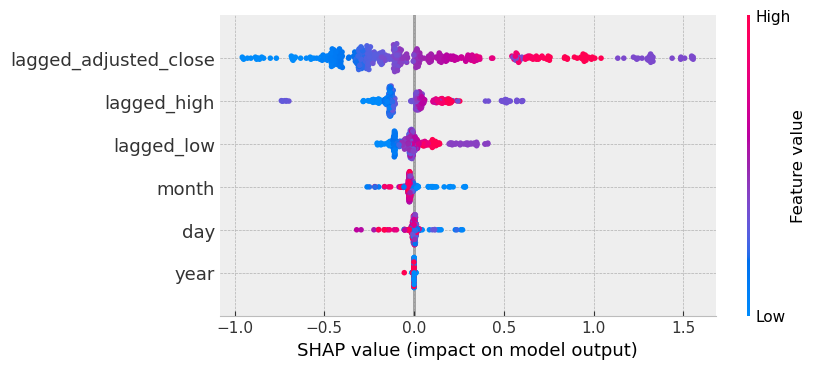

In [250]:



train_shap_values = explainer(X_train) 


shap.plots.beeswarm(train_shap_values)

In [65]:
!pwd

/Users/thomasnguyen/projects/news_project/notebooks


In [254]:
import joblib

In [ ]:
model.fea

In [68]:
import joblib 

joblib.dump(model, "/Users/thomasnguyen/projects/news_project/models/time_series/vinfast/vinfast_open_forecaster.pkl")

['/Users/thomasnguyen/projects/news_project/models/vinfast_open_forecaster.pkl']

In [230]:
import sys 
sys.path.append("../scripts/")
from clean_vinfast_stock import column_cleaner

In [63]:
model.feature_names_in_

array(['day', 'month', 'year', 'lagged_high_iqr_imputed',
       'lagged_low_iqr_imputed', 'lagged_adjusted_close_iqr_imputed'],
      dtype='<U33')

In [69]:
test = joblib.load('../models/time_series/vinfast/vinfast_open_forecaster.pkl') 
test.feature_names_in_

array(['day', 'month', 'year', 'lagged_high_iqr_imputed',
       'lagged_low_iqr_imputed', 'lagged_adjusted_close_iqr_imputed'],
      dtype='<U33')

In [266]:
print ("Predicting opening price for 5/05/2026")
first_may = pd.DataFrame({
    'day': [5],
    'month': [5],
    'year': [2026],
    'lagged_high_iqr_imputed': [4.27],
    'lagged_low_iqr_imputed': [4.16],
    'lagged_adjusted_close_iqr_imputed': [4.21]
 

    


})

mae = mean_absolute_error(y_true=Y_test, y_pred=pred)

first_may_cleaned = column_cleaner(first_may) 
first_may_cleaned = first_may_cleaned.clean_columns() 

prediction = model.predict(first_may_cleaned) 
print (f"Prediction: {prediction}")
print (f"upper bound: {prediction + mae}")
print (f"lower bound: {prediction - mae}")



Predicting opening price for 5/05/2026
   day  month  year  lagged_high_iqr_imputed  lagged_low_iqr_imputed  \
0    5      5  2026                     4.27                    4.16   

   lagged_adjusted_close_iqr_imputed  
0                               4.21  
Prediction: [4.2061234]
upper bound: [4.259579]
lower bound: [4.1526675]


In [267]:
first_may_cleaned

,day,month,year,lagged_high_iqr_imputed,lagged_low_iqr_imputed,lagged_adjusted_close_iqr_imputed
0,5,5,2026,4.27,4.16,4.21


In [268]:
mae

0.05345583822830863

# Training a "High" forecaster

In [269]:
import sys 
sys.path.append("../scripts/") 
from clean_time_series import clean_iqr

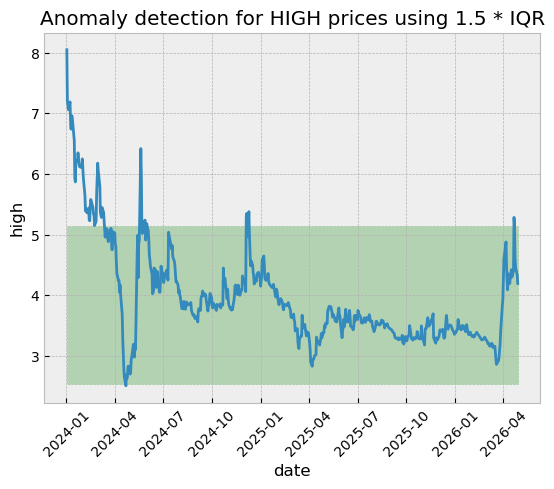

In [270]:
sns.lineplot(x=df.date, y=df.high)
plt.xticks(rotation=45)


# calculating upper and lower using iqr 
iqr = stats.iqr(df.high) 
upper = iqr + np.percentile(df.high, 75) 
lower = np.percentile(df.high, 25) - iqr 

plt.fill_between([df.date.min(), df.date.max()], lower, upper, color='g', alpha=.25, linestyle='--')

plt.title("Anomaly detection for HIGH prices using 1.5 * IQR")


plt.show()

In [271]:
# anomaly detection using isolation forest

from sklearn.ensemble import IsolationForest

# Prepare the data
high_anomalies = df[['high']].copy()

# Fit Isolation Forest
iso_forest = IsolationForest(
    contamination='auto',  # Expected proportion of anomalies (5%)
    random_state=42,
    n_estimators=100
)

df['anomaly'] = iso_forest.fit_predict(high_anomalies)
df['anomaly_score'] = iso_forest.decision_function(high_anomalies)

# -1 = anomaly, 1 = normal
df['is_anomaly'] = df['anomaly'] == -1

# View anomalies
anomalies = df[df['is_anomaly']][['date', 'high', 'anomaly_score']]
print(f"Found {len(anomalies)} anomalies out of {len(df)} records")
print(anomalies)

Found 152 anomalies out of 582 records
          date   high  anomaly_score
0   2024-01-02  8.050      -0.288611
1   2024-01-03  7.210      -0.226131
2   2024-01-04  7.130      -0.215402
3   2024-01-05  7.060      -0.210578
4   2024-01-08  7.190      -0.223678
..         ...    ...            ...
573 2026-04-16  4.420      -0.000534
576 2026-04-21  5.285      -0.026740
577 2026-04-22  5.120      -0.019841
578 2026-04-23  4.605      -0.043257
579 2026-04-24  4.450      -0.000533

[152 rows x 3 columns]


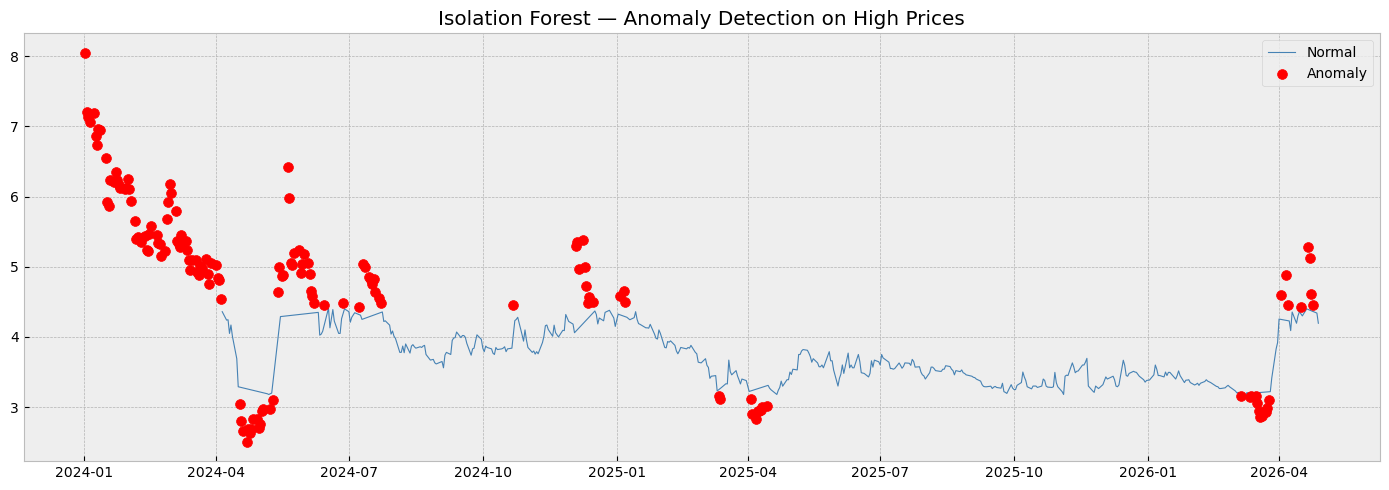

In [272]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

# Normal points
normal = df[~df['is_anomaly']]
ax.plot(normal['date'], normal['high'], color='steelblue', label='Normal', linewidth=0.8)

# Anomalies
ax.scatter(anomalies['date'], anomalies['high'],
           color='red', zorder=5, label='Anomaly', s=50)

ax.set_title('Isolation Forest — Anomaly Detection on High Prices')
ax.legend()
plt.tight_layout()
plt.show()

In [277]:
df.drop(['is_anomaly'],axis=1,inplace=True)


In [ ]:
df.drop

In [282]:
# predicting opening price 


# sorting the data by date
df.drop(['anomaly_score', 'anomaly'],axis=1,inplace=True)
df = df.sort_values(['date'],ascending=True)


X = df.drop(['close', 'volume', 'high'],axis=1) 


y = df.high.values.reshape(-1,1) 
# lagging the y
y_lag = np.delete(y, 0)


train_size=round(len(df) * 0.8)
test_size=round(len(df) * 0.2) 



# creating the train/test split 
X_train = X.head(train_size) 
X_test = X.tail(test_size) 

Y_train = y_lag[0:round(len(y_lag) * 0.8)]
Y_test = y_lag[train_size:np.shape(y)[0]]


# fittign the cleaner
X_train = clean_iqr(X_train) 
column_stats = X_train.fit() 

X_train_transformed = X_train.fit_transform()

X_test_transformed = X_train.transform(column_stats=column_stats, dataframe=X_test)


X_train_transformed = X_train.build_lagging(dataframe=X_train_transformed)
X_test_transformed=X_train.build_lagging(dataframe=X_test_transformed)


Calculating the upper, lower, median and iqr...
Analysing column: open
Analysing column: low
Analysing column: adjusted_close
Using the 1.5 * IQR method for anomaly detection...
Analysing column: open
Analysing column: low
Analysing column: adjusted_close
`day` is a datetime. Ignoring this...
`month` is a datetime. Ignoring this...
`year` is a datetime. Ignoring this...
Transforming... Dataframe
median: [3.75]
upper: [5.375]
lower: [2.295]
Transforming... Dataframe
median: [3.6875]
upper: [5.152875]
lower: [2.291875]
Transforming... Dataframe
median: [3.75]
upper: [5.42375]
lower: [2.23375]
Created the lagged values...
Removing the first row
Created the lagged values...
Removing the first row


/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:154: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df.drop(['date'],axis=1,inplace=True)
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:155: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df['day'] = self.df.index.day
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:156: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

In [284]:
X_train_transformed.drop(['open','low','adjusted_close', 'open_iqr_imputed', 'low_iqr_imputed', 'adjusted_close_iqr_imputed', 'lagged_open', 'lagged_low', 'lagged_adjusted_close'],axis=1,inplace=True)
X_test_transformed.drop(['open','low','adjusted_close', 'open_iqr_imputed', 'low_iqr_imputed', 'adjusted_close_iqr_imputed', 'lagged_open', 'lagged_low', 'lagged_adjusted_close'],axis=1,inplace=True)

/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_28351/1791771756.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_transformed.drop(['open','low','adjusted_close', 'open_iqr_imputed', 'low_iqr_imputed', 'adjusted_close_iqr_imputed', 'lagged_open', 'lagged_low', 'lagged_adjusted_close'],axis=1,inplace=True)
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_28351/1791771756.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_transformed.drop(['open','low','adjusted_close', 'open_iqr_imputed', 'low_iqr_imputed', 'adjusted_close_iqr_imputed', 'lagged_open', 'lagged_low', 'lagged_adjuste

In [ ]:
_t

In [285]:
np.shape(Y_train)
np.shape(X_train_transformed)
np.shape(Y_test)
np.shape(X_test_transformed)

(465,)

In [295]:
X_train_transformed.head()

,day,month,year,lagged_open_iqr_imputed,lagged_low_iqr_imputed,lagged_adjusted_close_iqr_imputed
date,,,,,,
2024-01-03,3,1,2024,3.75,3.6875,3.75
2024-01-04,4,1,2024,3.75,3.6875,3.75
2024-01-05,5,1,2024,3.75,3.6875,3.75
2024-01-08,8,1,2024,3.75,3.6875,3.75
2024-01-09,9,1,2024,3.75,3.6875,3.75


In [296]:
clf = XGBRegressor() 

clf.fit(X_train_transformed, Y_train) 

high_pred = clf.predict(X_test_transformed) 

print (r2_score(y_true=Y_test, y_pred=high_pred))

print (mean_absolute_error(y_true=Y_test, y_pred=high_pred))


print (root_mean_squared_error(y_true=Y_test, y_pred=high_pred))

clf_mae = mean_absolute_error(y_true=Y_test, y_pred=high_pred)

0.839078204963205
0.11943687881801439
0.18435432973610402


In [271]:
# attempting skopt bayes search
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer


In [272]:
param_grid = {
    'eta': Real(0.001, 0.5, prior='log-uniform'),
    'tree_method': Categorical(['auto', 'hist', 'exact', 'approx']),
    'max_depth': Integer(6, 50, prior='log-uniform'),
    'num_parallel_tree': Integer(1, 5)
    
}


grid_search = BayesSearchCV(
    estimator=XGBRegressor(n_estimators=30, min_child_weight=0),
    search_spaces=param_grid,
    verbose=3,
    return_train_score=True,
    cv=5,
    scoring='r2',
    n_iter=100,
    n_jobs=-1
)

_ = grid_search.fit(X_train, Y_train) 



Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 4/5] END eta=0.0018814045976110847, max_depth=6, num_parallel_tree=2, tree_method=hist;, score=(train=0.097, test=-7.632) total time=   0.0s
[CV 3/5] END eta=0.0018814045976110847, max_depth=6, num_parallel_tree=2, tree_method=hist;, score=(train=0.098, test=-0.034) total time=   0.0s
[CV 2/5] END eta=0.0018814045976110847, max_depth=6, num_parallel_tree=2, tree_method=hist;, score=(train=0.098, test=-0.168) total time=   0.0s
[CV 5/5] END eta=0.0018814045976110847, max_depth=6, num_parallel_tree=2, tree_method=hist;, score=(train=0.097, test=-28.826) total time=   0.0s
[CV 1/5] END eta=0.0018814045976110847, max_depth=6, num_parallel_tree=2, tree_method=hist;, score=(train=0.094, test=-0.742) total time=   0.0s
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 3/5] END eta=0.2247557242929123, max_depth=13, num_parallel_tree=4, tree_method=exact;, score=(train=1.000, test=-0.155) total time=   0.1s
[CV 4/5] END

/opt/miniconda3/envs/news_project/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [0.49999999999999994, 6, 5, 'auto'] before, using random point [0.04905579293774474, 6, 2, 'auto']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 1/5] END eta=0.04905579293774474, max_depth=6, num_parallel_tree=2, tree_method=auto;, score=(train=0.897, test=-0.388) total time=   0.0s
[CV 3/5] END eta=0.04905579293774474, max_depth=6, num_parallel_tree=2, tree_method=auto;, score=(train=0.922, test=0.528) total time=   0.0s
[CV 2/5] END eta=0.04905579293774474, max_depth=6, num_parallel_tree=2, tree_method=auto;, score=(train=0.925, test=0.546) total time=   0.0s
[CV 4/5] END eta=0.04905579293774474, max_depth=6, num_parallel_tree=2, tree_method=auto;, score=(train=0.917, test=0.176) total time=   0.0s
[CV 5/5] END eta=0.04905579293774474, max_depth=6, num_parallel_tree=2, tree_method=auto;, score=(train=0.916, test=-3.584) total time=   0.0s
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 1/5] END eta=0.17527333035869191, max_depth=6, num_parallel_tree=5, tree_method=hist;, score=(train=0.993, test=-0.233) total time=   0.1s
[CV 2/5] END eta=0.17527333

In [273]:
grid_pred = grid_search.predict(X_test) 

print (r2_score(y_true=Y_test, y_pred=grid_pred))

print (mean_absolute_error(y_true=Y_test, y_pred=grid_pred))


print (root_mean_squared_error(y_true=Y_test, y_pred=grid_pred))

clf_mae = mean_absolute_error(y_true=Y_test, y_pred=grid_pred)


0.8065729766878179
0.10499565827742866
0.20211776253684627


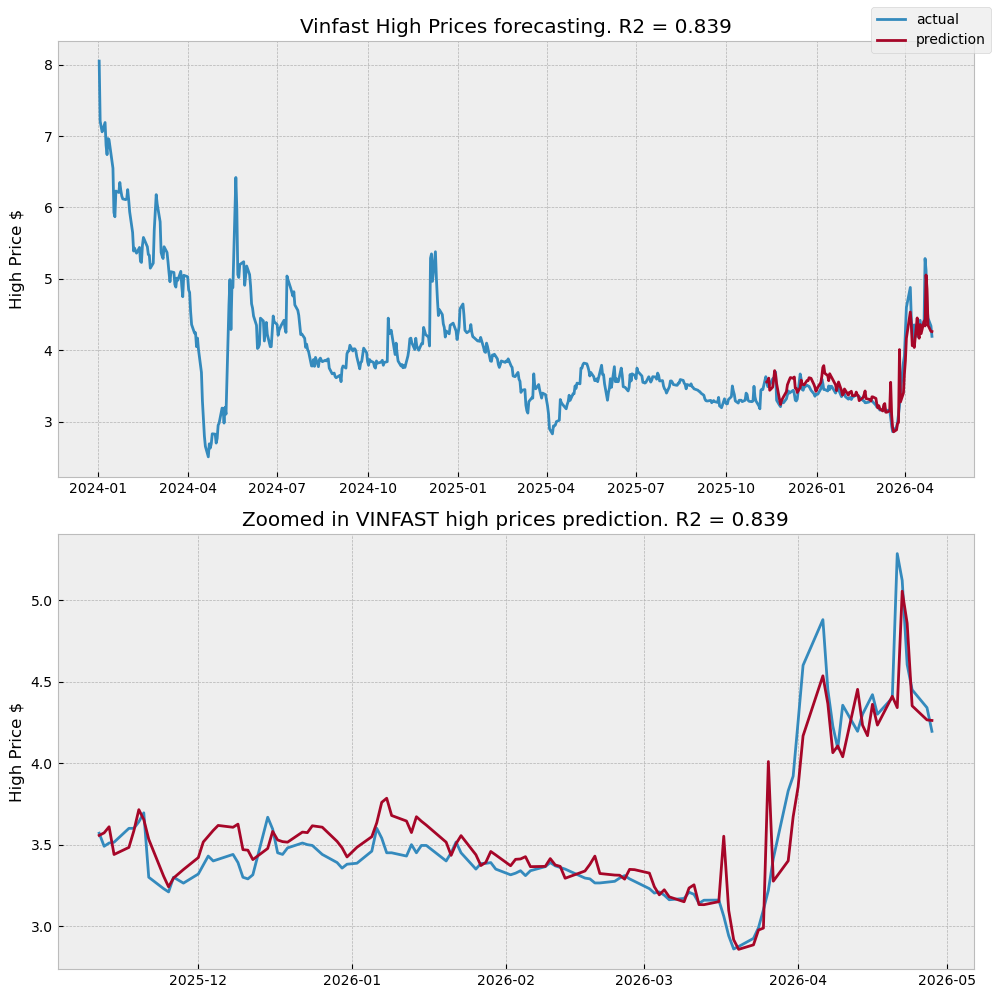

In [297]:
# plotting the lagged high 

# plotting

fig, axes=plt.subplots(2, figsize=(10,10))




axes[0].plot(df.date, df.high)
axes[0].plot(df.tail(test_size).date.iloc[1:], high_pred)



axes[0].set_title(f"Vinfast High Prices forecasting. R2 = {np.round(r2_score(y_true=Y_test, y_pred=high_pred), 3)}")
axes[0].set_ylabel("High Price $")

# ---------

axes[1].plot(df.tail(test_size).date.iloc[1:], Y_test)
axes[1].plot(df.tail(test_size).date.iloc[1:], high_pred)



axes[1].set_title(f"Zoomed in VINFAST high prices prediction. R2 = {np.round(r2_score(y_true=Y_test, y_pred=high_pred), 3)}")
axes[1].set_ylabel("High Price $")
fig.legend(['actual', 'prediction'])

fig.align_ylabels()

plt.tight_layout()
plt.show()



Text(0, 0.5, 'high pred')

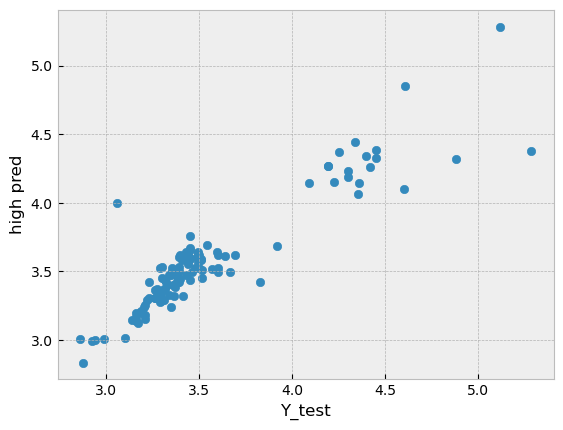

In [276]:
plt.scatter(Y_test, high_pred) 

plt.xlabel("Y_test") 
plt.ylabel("high pred")

In [298]:
X_train_transformed.columns

Index(['day', 'month', 'year', 'lagged_open_iqr_imputed',
       'lagged_low_iqr_imputed', 'lagged_adjusted_close_iqr_imputed'],
      dtype='object')

In [278]:
X_train.columns

Index(['day', 'month', 'year', 'lagged_adjusted_close', 'lagged_open',
       'lagged_low'],
      dtype='object')

In [299]:
# test prediction 

test_data1 = pd.DataFrame({
    'day': [5],
    'month':[5],
    'year':[2026],
    'lagged_open_iqr_imputed': [4.22],
    'lagged_low_iqr_imputed': [4.16],
    'lagged_adjusted_close_iqr_imputed': [4.21]
    



    



})
# cleaning 

print (test_data1)

test_data1_cleaned = column_cleaner(test_data1) 
test_data1_cleaned = test_data1_cleaned.clean_columns()



print ("Predicting the high for 5/05/2026")
test2_pred = clf.predict(test_data1_cleaned)
print (f"Prediction: {test2_pred}")
print (f"upper bound: {test2_pred + clf_mae}")
print (f"lower bound: {test2_pred - clf_mae}")


   day  month  year  lagged_open_iqr_imputed  lagged_low_iqr_imputed  \
0    5      5  2026                     4.22                    4.16   

   lagged_adjusted_close_iqr_imputed  
0                               4.21  
   day  month  year  lagged_open_iqr_imputed  lagged_low_iqr_imputed  \
0    5      5  2026                     4.22                    4.16   

   lagged_adjusted_close_iqr_imputed  
0                               4.21  
Predicting the high for 5/05/2026
Prediction: [4.3512125]
upper bound: [4.4706492]
lower bound: [4.2317758]


In [300]:
joblib.dump(clf, '../models/time_series/vinfast/vinfast_high_forecaster.pkl')

['../models/time_series/vinfast/vinfast_high_forecaster.pkl']

In [ ]:
# predicting opening priee 

In [288]:
df.head()

,date,open,high,low,close,adjusted_close,volume,day,month,year,open_imputed,anomaly,anomaly_score,is_anomaly,high_imputed
0,2024-01-02,8.040,8.05,7.000,7.05,7.05,6666200,2,1,2024,3.64,-1,-0.288611,True,3.74
1,2024-01-03,7.135,7.21,6.835,7.08,7.08,4709600,3,1,2024,3.64,-1,-0.226131,True,3.74
2,2024-01-04,7.070,7.13,6.900,7.07,7.07,3466600,4,1,2024,3.64,-1,-0.215402,True,3.74
3,2024-01-05,7.000,7.06,6.900,7.02,7.02,1939900,5,1,2024,3.64,-1,-0.210578,True,3.74
4,2024-01-08,7.050,7.19,6.750,6.79,6.79,3767900,8,1,2024,3.64,-1,-0.223678,True,3.74


In [289]:
df = df[['date', 'open', 'adjusted_close', 'close', 'high', 'low', 'day', 'month', 'year']]

In [290]:
df

,date,open,adjusted_close,close,high,low,day,month,year
0,2024-01-02,8.040,7.05,7.05,8.050,7.000,2,1,2024
1,2024-01-03,7.135,7.08,7.08,7.210,6.835,3,1,2024
2,2024-01-04,7.070,7.07,7.07,7.130,6.900,4,1,2024
3,2024-01-05,7.000,7.02,7.02,7.060,6.900,5,1,2024
4,2024-01-08,7.050,6.79,6.79,7.190,6.750,8,1,2024
...,...,...,...,...,...,...,...,...,...
577,2026-04-22,4.880,4.69,4.69,5.120,4.580,22,4,2026
578,2026-04-23,4.570,4.41,4.41,4.605,4.140,23,4,2026
579,2026-04-24,4.410,4.36,4.36,4.450,4.335,24,4,2026
580,2026-04-27,4.230,4.21,4.21,4.340,4.157,27,4,2026


In [291]:
import sys 
sys.path.append("../scripts/")
from clean_time_series import clean_iqr

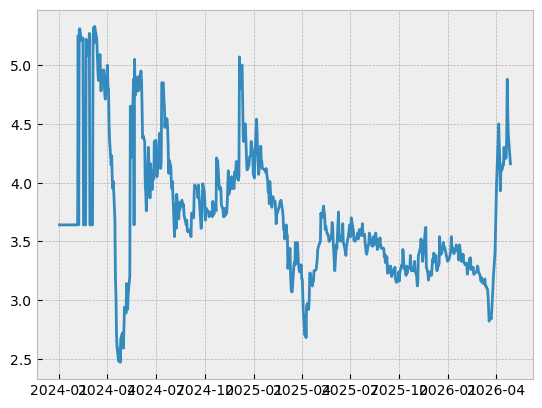

In [422]:
plt.plot(b_transformed.date, b_transformed.open_iqr_imputed)

In [298]:
df

,open,adjusted_close,close,high,low,day,month,year,open_iqr_imputed,adjusted_close_iqr_imputed,close_iqr_imputed,high_iqr_imputed,low_iqr_imputed
date,,,,,,,,,,,,,
2024-01-02,8.040,7.05,7.05,8.050,7.000,2,1,2024,3.64,3.62,3.62,3.740,3.5575
2024-01-03,7.135,7.08,7.08,7.210,6.835,3,1,2024,3.64,3.62,3.62,3.740,3.5575
2024-01-04,7.070,7.07,7.07,7.130,6.900,4,1,2024,3.64,3.62,3.62,3.740,3.5575
2024-01-05,7.000,7.02,7.02,7.060,6.900,5,1,2024,3.64,3.62,3.62,3.740,3.5575
2024-01-08,7.050,6.79,6.79,7.190,6.750,8,1,2024,3.64,3.62,3.62,3.740,3.5575
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-22,4.880,4.69,4.69,5.120,4.580,22,4,2026,4.88,4.69,4.69,5.120,4.5800
2026-04-23,4.570,4.41,4.41,4.605,4.140,23,4,2026,4.57,4.41,4.41,4.605,4.1400
2026-04-24,4.410,4.36,4.36,4.450,4.335,24,4,2026,4.41,4.36,4.36,4.450,4.3350


In [502]:
df.head()

,date,open,high,low,close,adjusted_close,volume
583,2024-01-02,8.040,8.05,7.000,7.05,7.05,6666200
584,2024-01-03,7.135,7.21,6.835,7.08,7.08,4709600
585,2024-01-04,7.070,7.13,6.900,7.07,7.07,3466600
586,2024-01-05,7.000,7.06,6.900,7.02,7.02,1939900
587,2024-01-08,7.050,7.19,6.750,6.79,6.79,3767900


# Creating a model for lower

In [299]:
import sys 
sys.path.append("../scripts/")
from clean_time_series import clean_iqr

          date   open   high    low  close  adjusted_close   volume
0   2024-01-02  8.040  8.050  7.000   7.05            7.05  6666200
1   2024-01-03  7.135  7.210  6.835   7.08            7.08  4709600
2   2024-01-04  7.070  7.130  6.900   7.07            7.07  3466600
3   2024-01-05  7.000  7.060  6.900   7.02            7.02  1939900
4   2024-01-08  7.050  7.190  6.750   6.79            6.79  3767900
..         ...    ...    ...    ...    ...             ...      ...
577 2026-04-22  4.880  5.120  4.580   4.69            4.69  1409000
578 2026-04-23  4.570  4.605  4.140   4.41            4.41  1333100
579 2026-04-24  4.410  4.450  4.335   4.36            4.36   457200
580 2026-04-27  4.230  4.340  4.157   4.21            4.21   650700
581 2026-04-28  4.160  4.195  4.000   4.06            4.06   834600

[582 rows x 7 columns]


In [ ]:
d

In [368]:
# predicting low price 


# sorting the data by date

df = df.sort_values(['date'],ascending=True)


X = df.drop(['close', 'volume', 'low'],axis=1) 


y = df.low.values.reshape(-1,1) 
# lagging the y
y_lag = np.delete(y, 0)


train_size=round(len(df) * 0.8)
test_size=round(len(df) * 0.2) 



# creating the train/test split 
X_train = X.head(train_size) 
X_test = X.tail(test_size) 

Y_train = y_lag[0:round(len(y_lag) * 0.8)]
Y_test = y_lag[train_size:np.shape(y)[0]]


# fittign the cleaner
X_train = clean_iqr(X_train) 
column_stats = X_train.fit() 

X_train_transformed = X_train.fit_transform()

X_test_transformed = X_train.transform(column_stats=column_stats, dataframe=X_test)


X_train_transformed = X_train.build_lagging(dataframe=X_train_transformed)
X_test_transformed=X_train.build_lagging(dataframe=X_test_transformed)

print (X_train_transformed.head()) 
print (X_test_transformed.head())

Calculating the upper, lower, median and iqr...
Analysing column: open
Analysing column: high
Analysing column: adjusted_close
Using the 1.5 * IQR method for anomaly detection...
Analysing column: open
Analysing column: high
Analysing column: adjusted_close
`day` is a datetime. Ignoring this...
`month` is a datetime. Ignoring this...
`year` is a datetime. Ignoring this...
Transforming... Dataframe
median: [3.75]
upper: [5.375]
lower: [2.295]
Transforming... Dataframe
median: [3.83]
upper: [5.6625]
lower: [2.1865]
Transforming... Dataframe
median: [3.75]
upper: [5.42375]
lower: [2.23375]
Created the lagged values...
Removing the first row
Created the lagged values...
Removing the first row
             open  high  adjusted_close  day  month  year  open_iqr_imputed  \
date                                                                          
2024-01-03  7.135  7.21            7.08    3      1  2024              3.75   
2024-01-04  7.070  7.13            7.07    4      1  2024        

/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:154: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df.drop(['date'],axis=1,inplace=True)
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:155: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df['day'] = self.df.index.day
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:156: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

In [369]:
X_test_transformed.drop(['open', 'high', 'adjusted_close', 'open_iqr_imputed', 'high_iqr_imputed', 'adjusted_close_iqr_imputed', 'lagged_open', 'lagged_high', 'lagged_adjusted_close'], axis=1,inplace=True)


X_train_transformed.drop(['open', 'high', 'adjusted_close', 'open_iqr_imputed', 'high_iqr_imputed', 'adjusted_close_iqr_imputed', 'lagged_open', 'lagged_high', 'lagged_adjusted_close'], axis=1,inplace=True)


/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_28351/3580169678.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_transformed.drop(['open', 'high', 'adjusted_close', 'open_iqr_imputed', 'high_iqr_imputed', 'adjusted_close_iqr_imputed', 'lagged_open', 'lagged_high', 'lagged_adjusted_close'], axis=1,inplace=True)
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_28351/3580169678.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_transformed.drop(['open', 'high', 'adjusted_close', 'open_iqr_imputed', 'high_iqr_imputed', 'adjusted_close_iqr_imputed', 'lagged_open', 'lagged_high', 'lag

In [370]:
X_train_transformed.head()

,day,month,year,lagged_open_iqr_imputed,lagged_high_iqr_imputed,lagged_adjusted_close_iqr_imputed
date,,,,,,
2024-01-03,3,1,2024,3.75,3.83,3.75
2024-01-04,4,1,2024,3.75,3.83,3.75
2024-01-05,5,1,2024,3.75,3.83,3.75
2024-01-08,8,1,2024,3.75,3.83,3.75
2024-01-09,9,1,2024,3.75,3.83,3.75


In [371]:
print (np.shape(Y_train))
print (np.shape(X_train_transformed))
print ("----") 
print (np.shape(Y_test)) 
print (np.shape(X_test_transformed))

(465,)
(465, 6)
----
(115,)
(115, 6)


In [372]:
from xgboost import XGBRegressor

In [373]:
low_clf = XGBRegressor(min_child_weight=0, eta=0.3, max_depth=6) 

low_clf.fit(X_train_transformed, Y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [374]:
low_pred = low_clf.predict(X_test_transformed)

In [375]:
# metrics 
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, median_absolute_error, mean_squared_error


In [376]:
print (f"r2: {r2_score(y_true=Y_test, y_pred=low_pred)}")
print (f"mean ae: {mean_absolute_error(y_true=Y_test, y_pred=low_pred)}")
print (F"median ae: {median_absolute_error(y_true=Y_test, y_pred=low_pred)}")
print (f"rmse: {root_mean_squared_error(y_true=Y_test, y_pred=low_pred)}")
print (f"mse: {mean_squared_error(y_true=Y_test, y_pred=low_pred)}")

r2: 0.9186922036217592
mean ae: 0.07186069891556447
median ae: 0.05793404579162598
rmse: 0.10089373208035328
mse: 0.010179545173102109


In [377]:
import joblib

In [378]:
joblib.dump(low_clf, '../models/time_series/vinfast/vinfast_low_forecaster.pkl')

['../models/time_series/vinfast/vinfast_low_forecaster.pkl']

<Axes: >

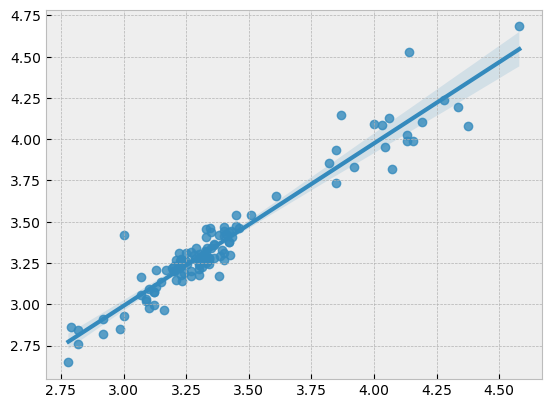

In [379]:
# plotting the results

sns.regplot(x=Y_test, y=low_pred)


# building a model for adjusted close

In [338]:
import joblib 
from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real

In [339]:
df

,date,open,high,low,close,adjusted_close,volume
0,2024-01-02,8.040,8.050,7.000,7.05,7.05,6666200
1,2024-01-03,7.135,7.210,6.835,7.08,7.08,4709600
2,2024-01-04,7.070,7.130,6.900,7.07,7.07,3466600
3,2024-01-05,7.000,7.060,6.900,7.02,7.02,1939900
4,2024-01-08,7.050,7.190,6.750,6.79,6.79,3767900
...,...,...,...,...,...,...,...
577,2026-04-22,4.880,5.120,4.580,4.69,4.69,1409000
578,2026-04-23,4.570,4.605,4.140,4.41,4.41,1333100
579,2026-04-24,4.410,4.450,4.335,4.36,4.36,457200
580,2026-04-27,4.230,4.340,4.157,4.21,4.21,650700


In [340]:
import sys 
sys.path.append("../scripts/")
from clean_time_series import clean_iqr

In [341]:
df.head()

,date,open,high,low,close,adjusted_close,volume
0,2024-01-02,8.040,8.05,7.000,7.05,7.05,6666200
1,2024-01-03,7.135,7.21,6.835,7.08,7.08,4709600
2,2024-01-04,7.070,7.13,6.900,7.07,7.07,3466600
3,2024-01-05,7.000,7.06,6.900,7.02,7.02,1939900
4,2024-01-08,7.050,7.19,6.750,6.79,6.79,3767900


In [380]:
# predicting the adjusted close

X = df[['date', 'open', 'high', 'low']]
y = df.adjusted_close.values.reshape(-1,1) 
TRAIN_SIZE=round(df.shape[0] * 0.8)
TEST_SIZE = round(df.shape[0] * 0.2) 


X_train = X.head(TRAIN_SIZE)
X_test=X.tail(TEST_SIZE)



In [381]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 466 to 581
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    116 non-null    datetime64[ns]
 1   open    116 non-null    float64       
 2   high    116 non-null    float64       
 3   low     116 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 3.8 KB


In [382]:
Y_train = y[0:TRAIN_SIZE]
Y_test = y[TRAIN_SIZE:len(y)]

Y_train_lag = Y_train[1:]
Y_test_lag = Y_test[1:]

In [383]:
np.shape(Y_test)

(116, 1)

In [384]:
X_train

,date,open,high,low
0,2024-01-02,8.040,8.050,7.000
1,2024-01-03,7.135,7.210,6.835
2,2024-01-04,7.070,7.130,6.900
3,2024-01-05,7.000,7.060,6.900
4,2024-01-08,7.050,7.190,6.750
...,...,...,...,...
461,2025-11-03,3.200,3.220,3.130
462,2025-11-04,3.120,3.180,3.100
463,2025-11-05,3.150,3.440,3.140
464,2025-11-06,3.380,3.455,3.295


In [385]:
clean_iqr_X_train = clean_iqr(X_train)

column_stats = clean_iqr_X_train.fit() 
X_train_transformed = clean_iqr_X_train.fit_transform()
print ("-----------------------------------")
X_test_transformed = clean_iqr_X_train.transform(column_stats, dataframe=X_test)


Calculating the upper, lower, median and iqr...
Analysing column: open
Analysing column: high
Analysing column: low
Using the 1.5 * IQR method for anomaly detection...
Analysing column: open
Analysing column: high
Analysing column: low
`day` is a datetime. Ignoring this...
`month` is a datetime. Ignoring this...
`year` is a datetime. Ignoring this...
-----------------------------------
Transforming... Dataframe
median: [3.75]
upper: [5.375]
lower: [2.295]
Transforming... Dataframe
median: [3.83]
upper: [5.6625]
lower: [2.1865]
Transforming... Dataframe
median: [3.6875]
upper: [5.152875]
lower: [2.291875]


/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:154: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df.drop(['date'],axis=1,inplace=True)
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:155: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df['day'] = self.df.index.day
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:156: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

In [386]:
column_stats

,column,iqr,median,upper,lower
0,open,0.77000,3.7500,5.375000,2.295000
1,high,0.86900,3.8300,5.662500,2.186500
2,low,0.71525,3.6875,5.152875,2.291875


In [387]:
X_test_transformed

,open,high,low,day,month,year,open_iqr_imputed,high_iqr_imputed,low_iqr_imputed
date,,,,,,,,,
2025-11-10,3.45,3.630,3.420,10,11,2025,3.45,3.630,3.420
2025-11-11,3.52,3.570,3.460,11,11,2025,3.52,3.570,3.460
2025-11-12,3.46,3.490,3.400,12,11,2025,3.46,3.490,3.400
2025-11-13,3.50,3.510,3.330,13,11,2025,3.50,3.510,3.330
2025-11-14,3.33,3.515,3.330,14,11,2025,3.33,3.515,3.330
...,...,...,...,...,...,...,...,...,...
2026-04-22,4.88,5.120,4.580,22,4,2026,4.88,5.120,4.580
2026-04-23,4.57,4.605,4.140,23,4,2026,4.57,4.605,4.140
2026-04-24,4.41,4.450,4.335,24,4,2026,4.41,4.450,4.335


In [388]:
X_train_transformed

,open,high,low,day,month,year,open_iqr_imputed,high_iqr_imputed,low_iqr_imputed
date,,,,,,,,,
2024-01-02,8.040,8.050,7.000,2,1,2024,3.75,3.830,3.6875
2024-01-03,7.135,7.210,6.835,3,1,2024,3.75,3.830,3.6875
2024-01-04,7.070,7.130,6.900,4,1,2024,3.75,3.830,3.6875
2024-01-05,7.000,7.060,6.900,5,1,2024,3.75,3.830,3.6875
2024-01-08,7.050,7.190,6.750,8,1,2024,3.75,3.830,3.6875
...,...,...,...,...,...,...,...,...,...
2025-11-03,3.200,3.220,3.130,3,11,2025,3.20,3.220,3.1300
2025-11-04,3.120,3.180,3.100,4,11,2025,3.12,3.180,3.1000
2025-11-05,3.150,3.440,3.140,5,11,2025,3.15,3.440,3.1400


In [389]:
X_train_transformed.drop(['open', 'high', 'low'],axis=1,inplace=True) 
X_test_transformed.drop(['open', 'high', 'low'],axis=1,inplace=True)

/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_28351/2023342621.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_transformed.drop(['open', 'high', 'low'],axis=1,inplace=True)
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_28351/2023342621.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_transformed.drop(['open', 'high', 'low'],axis=1,inplace=True)


In [390]:
X_train_transformed_lag = clean_iqr_X_train.build_lagging(dataframe=X_train_transformed)
X_test_transformed_lag = clean_iqr_X_train.build_lagging(dataframe=X_test_transformed)

Created the lagged values...
Removing the first row
Created the lagged values...
Removing the first row


/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:253: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe[f"lagged_{column}"] = lagged_values
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:253: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe[f"lagged_{column}"] = lagged_values
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:253: SettingWithCopyWarning: 
A value is trying to be set on a cop

In [391]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 116 entries, 2025-11-10 to 2026-04-28
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   day                      116 non-null    int32  
 1   month                    116 non-null    int32  
 2   year                     116 non-null    int32  
 3   open_iqr_imputed         116 non-null    float64
 4   high_iqr_imputed         116 non-null    float64
 5   low_iqr_imputed          116 non-null    float64
 6   lagged_open_iqr_imputed  116 non-null    float64
 7   lagged_high_iqr_imputed  116 non-null    float64
 8   lagged_low_iqr_imputed   116 non-null    float64
dtypes: float64(6), int32(3)
memory usage: 7.7 KB


In [392]:
X_train_transformed_lag.drop(['open_iqr_imputed', 'high_iqr_imputed', 'low_iqr_imputed'],axis=1,inplace=True)
X_test_transformed_lag.drop(['open_iqr_imputed', 'high_iqr_imputed', 'low_iqr_imputed'],axis=1,inplace=True)


/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_28351/477915573.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_transformed_lag.drop(['open_iqr_imputed', 'high_iqr_imputed', 'low_iqr_imputed'],axis=1,inplace=True)
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_28351/477915573.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_transformed_lag.drop(['open_iqr_imputed', 'high_iqr_imputed', 'low_iqr_imputed'],axis=1,inplace=True)


In [402]:
X_test_transformed_lag.columns

Index(['day', 'month', 'year', 'lagged_open_iqr_imputed',
       'lagged_high_iqr_imputed', 'lagged_low_iqr_imputed'],
      dtype='object')

In [403]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, median_absolute_error, root_mean_squared_error, mean_squared_error

In [404]:
close_clf = XGBRegressor()
close_clf.fit(X_train_transformed_lag, Y_train_lag)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [405]:
close_pred = close_clf.predict(X_test_transformed_lag)

In [406]:
print (f"r2: {r2_score(y_true=Y_test_lag, y_pred=close_pred)}")
print (f"mean ae: {mean_absolute_error(y_true=Y_test_lag, y_pred=close_pred)}")
print (F"median ae: {median_absolute_error(y_true=Y_test_lag, y_pred=close_pred)}")
print (f"rmse: {root_mean_squared_error(y_true=Y_test_lag, y_pred=close_pred)}")
print (f"mse: {mean_squared_error(y_true=Y_test_lag, y_pred=close_pred)}")

r2: 0.8479684474543545
mean ae: 0.10302193434342097
median ae: 0.07076977729797385
rmse: 0.15436524135826823
mse: 0.023828627739596403


In [407]:
joblib.dump(close_clf, '../models/time_series/vinfast/vinfast_adjusted_close_forecaster.pkl')

['../models/time_series/vinfast/vinfast_adjusted_close_forecaster.pkl']

In [409]:
X_train_transformed_lag

,day,month,year,lagged_open_iqr_imputed,lagged_high_iqr_imputed,lagged_low_iqr_imputed
date,,,,,,
2024-01-03,3,1,2024,3.75,3.830,3.6875
2024-01-04,4,1,2024,3.75,3.830,3.6875
2024-01-05,5,1,2024,3.75,3.830,3.6875
2024-01-08,8,1,2024,3.75,3.830,3.6875
2024-01-09,9,1,2024,3.75,3.830,3.6875
...,...,...,...,...,...,...
2025-11-03,3,11,2025,3.25,3.290,3.2000
2025-11-04,4,11,2025,3.20,3.220,3.1300
2025-11-05,5,11,2025,3.12,3.180,3.1000


# predicting for 07/05/2026

In [383]:
import sys 
sys.path.append("../scripts/") 
from clean_time_series import clean_iqr 
from clean_vinfast_stock import column_cleaner
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np


In [416]:
# importing the models
open_clf = joblib.load("../models/time_series/vinfast/vinfast_open_forecaster.pkl") 
high_clf = joblib.load("../models/time_series/vinfast/vinfast_high_forecaster.pkl") 
low_clf = joblib.load("../models/time_series/vinfast/vinfast_low_forecaster.pkl") 
close_clf = joblib.load("../models/time_series/vinfast/vinfast_adjusted_close_forecaster.pkl")


In [417]:
open_clf.feature_names_in_

array(['day', 'month', 'year', 'lagged_adjusted_close', 'lagged_high',
       'lagged_low'], dtype='<U21')

In [413]:
high_clf.feature_names_in_ 


array(['day', 'month', 'year', 'lagged_open_iqr_imputed',
       'lagged_low_iqr_imputed', 'lagged_adjusted_close_iqr_imputed'],
      dtype='<U33')

In [414]:
low_clf.feature_names_in_ 

array(['day', 'month', 'year', 'lagged_open_iqr_imputed',
       'lagged_high_iqr_imputed', 'lagged_adjusted_close_iqr_imputed'],
      dtype='<U33')

In [415]:
close_clf.feature_names_in_

array(['day', 'month', 'year', 'lagged_open_iqr_imputed',
       'lagged_high_iqr_imputed', 'lagged_low_iqr_imputed'], dtype='<U23')